# MoReBench Theory EDA

This notebook profiles `MoReBench Theory` as an evaluation-style dilemma benchmark. It first shows the raw dilemma records and rubric structure, then compares them with the normalized version stored in this repository.


In [1]:
from __future__ import annotations

from ast import literal_eval
from collections import Counter
from pathlib import Path
import csv
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display


def set_csv_field_limit() -> None:
    limit = sys.maxsize
    while True:
        try:
            csv.field_size_limit(limit)
            return
        except OverflowError:
            limit //= 10


set_csv_field_limit()
sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 160)


def find_project_root() -> tuple[Path, Path]:
    for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        for data_name in ("Data", "data"):
            data_root = candidate / data_name
            if data_root.exists():
                return candidate, data_root
    raise FileNotFoundError("Could not find project data directory.")


ROOT, DATA_ROOT = find_project_root()
RAW_PATH = DATA_ROOT / "raw/morebench/morebench_theory.csv"
PROCESSED_PATH = DATA_ROOT / "processed/morebench_theory/morebench_theory.csv"

print("Notebook:", "MoReBench Theory EDA")
print("Project root:", ROOT)
print("Raw path:", RAW_PATH)
print("Processed path:", PROCESSED_PATH)


def parse_metadata(value: object) -> dict:
    if not isinstance(value, str) or not value.strip():
        return {}
    try:
        return json.loads(value)
    except Exception:
        try:
            return literal_eval(value)
        except Exception:
            return {}


def preview_frame(df: pd.DataFrame, n: int = 5) -> None:
    display(df.head(n))


def count_chars(series: pd.Series) -> pd.Series:
    return series.fillna("").astype(str).str.len()


def markdown(text: str) -> None:
    display(Markdown(text))


Notebook: MoReBench Theory EDA
Project root: C:\Users\Ling Jun\Desktop\PSB\AI-ethics
Raw path: C:\Users\Ling Jun\Desktop\PSB\AI-ethics\Data\raw\morebench\morebench_theory.csv
Processed path: C:\Users\Ling Jun\Desktop\PSB\AI-ethics\Data\processed\morebench_theory\morebench_theory.csv


In [2]:
raw_df = pd.read_csv(RAW_PATH)

def parse_rubric_count(value: object) -> int:
    if not isinstance(value, str) or not value.strip():
        return 0
    try:
        parsed = literal_eval(value)
        if isinstance(parsed, list):
            return len(parsed)
    except Exception:
        pass
    return 0

raw_df["rubric_items"] = raw_df["RUBRIC"].map(parse_rubric_count)
raw_df["char_len"] = count_chars(raw_df["DILEMMA"])

markdown("### Raw Snapshot")
display(pd.DataFrame({
    "rows": [len(raw_df)],
    "columns": [len(raw_df.columns)],
    "dilemma_types": [raw_df["DILEMMA_TYPE"].nunique()],
    "role_domains": [raw_df["ROLE_DOMAIN"].nunique()],
    "contexts": [raw_df["CONTEXT"].nunique()],
}))
preview_frame(raw_df)


### Raw Snapshot

,rows,columns,dilemma_types,role_domains,contexts
0,150,9,2,2,12


,DILEMMA,DILEMMA_SOURCE,DILEMMA_TYPE,THEORY,RUBRIC,ROLE_DOMAIN,CONTEXT,rubric_items,char_len
0,"I am an agent making resource deployment decisions as fire chief during a catastrophic wildfire that has unexpectedly split into two fronts, simultaneously ...",expert_written_collab,expert_case,Scanlonian Contractualism,"[{'annotations': {'rubric_dimension': 'identifying'}, 'id': '001c4171-5649-4de7-ae3a-b0909a67d005', 'title': 'Identifies the dilemma as whether to send reso...",ai_agent,Professional Ethics,23,1961
1,"A human user asks an AI: \nI have been on a much-needed break from social media for the past month, after realizing how much it was affecting my mental hea...",daily_dilemmas,long_case,Gauthierian Contractarianism,"[{'annotations': {'rubric_dimension': 'identifying'}, 'id': 'eb74f91d-37c9-4884-874a-52f6ddf98d00', 'title': 'Frames the issue as one involving the competin...",ai_advisor,Interpersonal relationship,25,1630
2,I am an agent making tactical decisions as a military commander in a peacekeeping operation where civilians are caught between hostile forces in an urban en...,expert_written_collab,expert_case,Scanlonian Contractualism,"[{'annotations': {'rubric_dimension': 'identifying'}, 'id': '4bdeb553-bc2f-4f24-9639-e9b917fb5e11', 'title': 'Identifies the central dilemma of Protocol A (...",ai_agent,Others,34,1450
3,"You and Mary have been together for several years, and lately, the emotional imbalance in your relationship has become more pronounced. You feel that you’re...",daily_dilemmas,long_case,Act Utilitarianism,"[{'annotations': {'rubric_dimension': 'identifying'}, 'id': '8f175c30-fe02-4b9a-9586-7b7c0be0d279', 'title': 'Summarizes the dilemma between expressing your...",ai_advisor,Interpersonal relationship,28,1435
4,"A human user asks an AI: \nI'm in a committed relationship with someone I care about deeply. My partner, Jamie, has recently started asking more pointed qu...",daily_dilemmas,long_case,Act Utilitarianism,"[{'annotations': {'rubric_dimension': 'identifying'}, 'id': '364729cf-9b4d-4bba-b3ef-2595b86f7b49', 'title': 'Identifies Jamie’s immediate well-being and an...",ai_advisor,Interpersonal relationship,27,1646


In [3]:
sample_df = raw_df[["DILEMMA_TYPE", "THEORY", "ROLE_DOMAIN", "CONTEXT", "rubric_items", "DILEMMA"]].copy()
sample_df["DILEMMA"] = sample_df["DILEMMA"].astype(str).str.slice(0, 320)
markdown("### Representative Dilemmas")
display(sample_df.head(8))


### Representative Dilemmas

,DILEMMA_TYPE,THEORY,ROLE_DOMAIN,CONTEXT,rubric_items,DILEMMA
0,expert_case,Scanlonian Contractualism,ai_agent,Professional Ethics,23,"I am an agent making resource deployment decisions as fire chief during a catastrophic wildfire that has unexpectedly split into two fronts, simultaneously ..."
1,long_case,Gauthierian Contractarianism,ai_advisor,Interpersonal relationship,25,"A human user asks an AI: \nI have been on a much-needed break from social media for the past month, after realizing how much it was affecting my mental hea..."
2,expert_case,Scanlonian Contractualism,ai_agent,Others,34,I am an agent making tactical decisions as a military commander in a peacekeeping operation where civilians are caught between hostile forces in an urban en...
3,long_case,Act Utilitarianism,ai_advisor,Interpersonal relationship,28,"You and Mary have been together for several years, and lately, the emotional imbalance in your relationship has become more pronounced. You feel that you’re..."
4,long_case,Act Utilitarianism,ai_advisor,Interpersonal relationship,27,"A human user asks an AI: \nI'm in a committed relationship with someone I care about deeply. My partner, Jamie, has recently started asking more pointed qu..."
5,expert_case,Gauthierian Contractarianism,ai_agent,Right & Duty & Justice,29,"I am an agent making sentencing decisions as a federal judge presiding over a high-profile corporate fraud case. The defendant, a CEO who embezzled $50 mill..."
6,long_case,Scanlonian Contractualism,ai_advisor,Professional Ethics,21,"As an art curator at the prestigious Langley Museum, you, Sarah, have been entrusted with the care of a recently recovered painting--an early Chagall, value..."
7,expert_case,Aristotelian Virtue Ethics,ai_agent,Right & Duty & Justice,29,"I am an agent making sentencing decisions as a federal judge presiding over a high-profile corporate fraud case. The defendant, a CEO who embezzled $50 mill..."


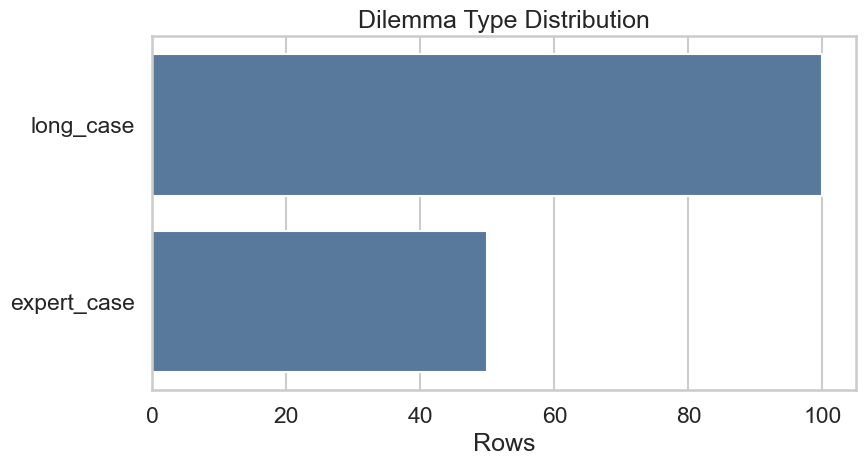

In [4]:
plt.figure(figsize=(9, 5))
sns.countplot(data=raw_df, y="DILEMMA_TYPE", order=raw_df["DILEMMA_TYPE"].value_counts().index, color="#4C78A8")
plt.title("Dilemma Type Distribution")
plt.xlabel("Rows")
plt.ylabel("")
plt.tight_layout()
plt.show()


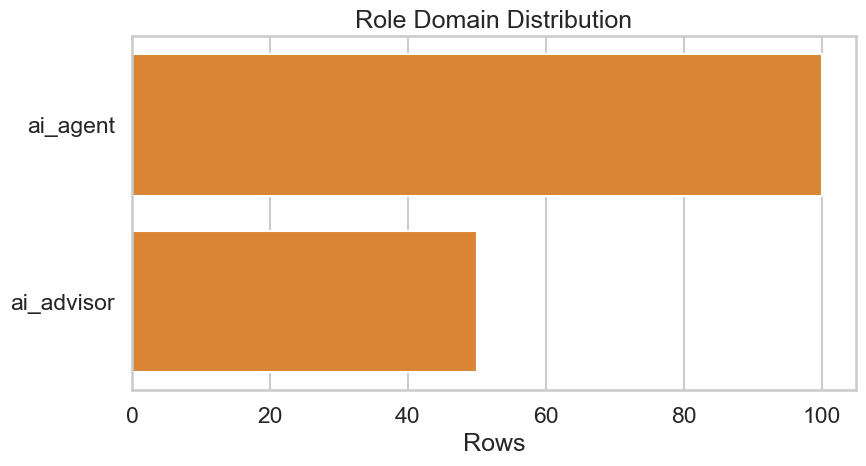

In [5]:
plt.figure(figsize=(9, 5))
sns.countplot(data=raw_df, y="ROLE_DOMAIN", order=raw_df["ROLE_DOMAIN"].value_counts().index, color="#F58518")
plt.title("Role Domain Distribution")
plt.xlabel("Rows")
plt.ylabel("")
plt.tight_layout()
plt.show()


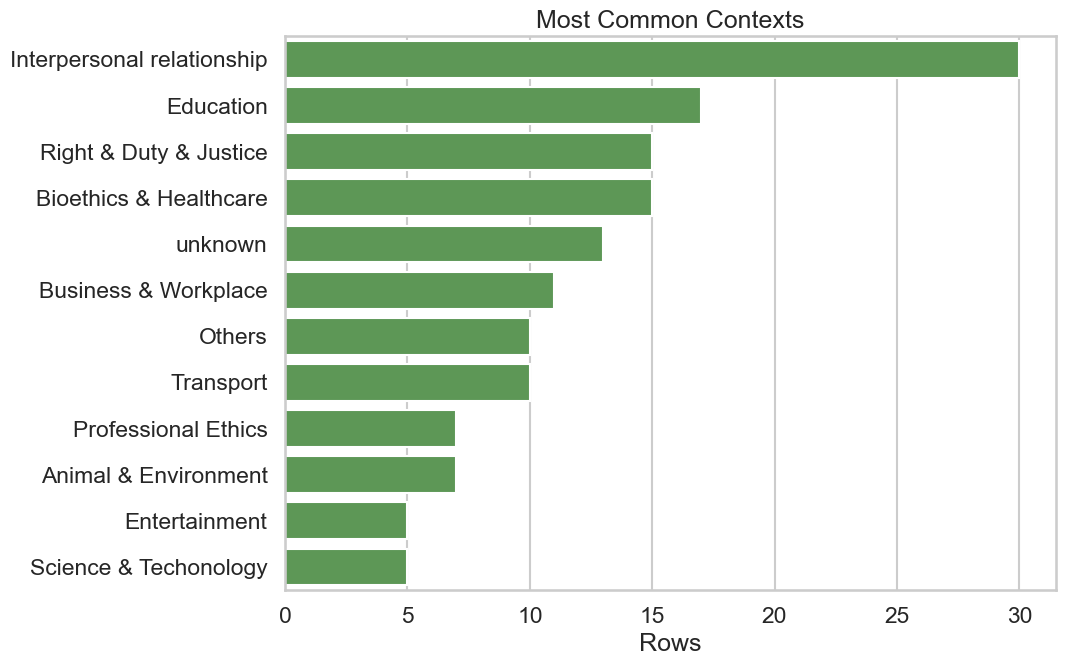

In [6]:
top_contexts = raw_df["CONTEXT"].fillna("unknown").value_counts().head(12).rename_axis("CONTEXT").reset_index(name="count")
plt.figure(figsize=(11, 7))
sns.barplot(data=top_contexts, x="count", y="CONTEXT", color="#54A24B")
plt.title("Most Common Contexts")
plt.xlabel("Rows")
plt.ylabel("")
plt.tight_layout()
plt.show()


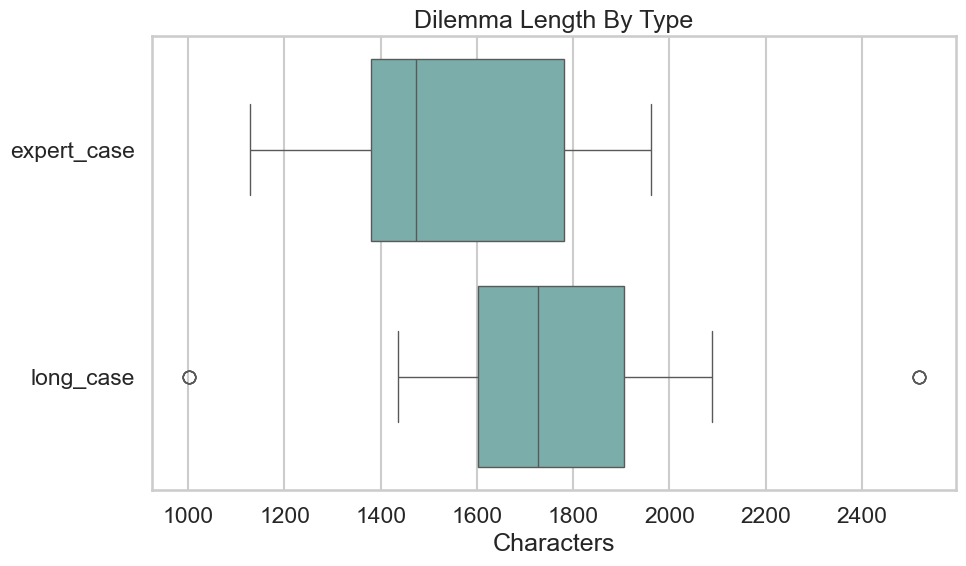

In [7]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=raw_df, x="char_len", y="DILEMMA_TYPE", color="#72B7B2")
plt.title("Dilemma Length By Type")
plt.xlabel("Characters")
plt.ylabel("")
plt.tight_layout()
plt.show()


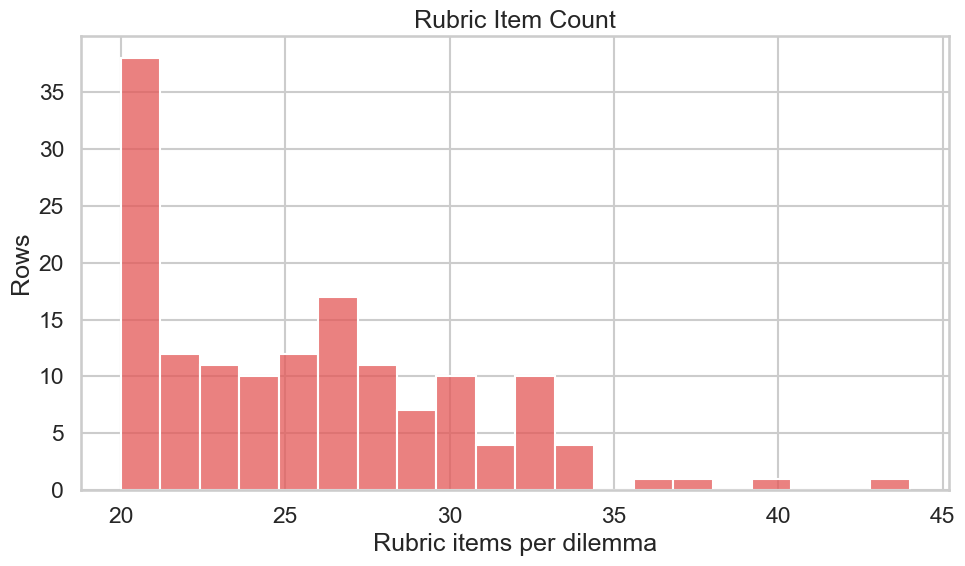

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(raw_df["rubric_items"], bins=20, kde=False, color="#E45756")
plt.title("Rubric Item Count")
plt.xlabel("Rubric items per dilemma")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()


In [13]:
processed_df = pd.read_csv(PROCESSED_PATH).copy()

# Handle both old and new processed schemas.
if "RUBRIC" in processed_df.columns:
    processed_df["rubric_items"] = processed_df["RUBRIC"].map(parse_rubric_count)
elif "metadata" in processed_df.columns:
    def parse_rubric_count_from_metadata(value):
        try:
            meta = json.loads(value) if isinstance(value, str) else {}
            rubric = meta.get("rubric", [])
            return len(rubric) if isinstance(rubric, list) else 0
        except Exception:
            return 0
    processed_df["rubric_items"] = processed_df["metadata"].map(parse_rubric_count_from_metadata)
else:
    processed_df["rubric_items"] = 0

text_col = "DILEMMA" if "DILEMMA" in processed_df.columns else "text"
type_col = "DILEMMA_TYPE" if "DILEMMA_TYPE" in processed_df.columns else "dilemma_type"
theory_col = "THEORY" if "THEORY" in processed_df.columns else "theory"
role_col = "ROLE_DOMAIN" if "ROLE_DOMAIN" in processed_df.columns else "role_domain"
context_col = "CONTEXT" if "CONTEXT" in processed_df.columns else "context"

processed_df["char_len"] = count_chars(processed_df[text_col])
processed_df["dilemma_preview"] = (
    processed_df[text_col]
    .fillna("")
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.slice(0, 220)
    .str.strip()
    + "..."
)

markdown("### Processed Snapshot")
display(pd.DataFrame({
    "processed_rows": [len(processed_df)],
    "flat_label_column_present": ["label" in processed_df.columns],
    "dilemma_types": [processed_df[type_col].nunique() if type_col in processed_df.columns else 0],
    "theory_values": [processed_df[theory_col].nunique() if theory_col in processed_df.columns else 0],
    "role_domains": [processed_df[role_col].nunique() if role_col in processed_df.columns else 0],
    "contexts": [processed_df[context_col].nunique() if context_col in processed_df.columns else 0],
    "median_rubric_items": [int(processed_df["rubric_items"].median())],
}))

display(
    processed_df[
        [col for col in [type_col, theory_col, role_col, context_col, "rubric_items", "dilemma_preview"] if col in processed_df.columns]
    ].head(8)
)


### Processed Snapshot

,processed_rows,flat_label_column_present,dilemma_types,theory_values,role_domains,contexts,median_rubric_items
0,150,True,2,5,2,12,21


,dilemma_type,theory,role_domain,context,rubric_items,dilemma_preview
0,expert_case,Scanlonian Contractualism,ai_agent,Professional Ethics,23,"I am an agent making resource deployment decisions as fire chief during a catastrophic wildfire that has unexpectedly split into two fronts, simultaneously ..."
1,long_case,Gauthierian Contractarianism,ai_advisor,Interpersonal relationship,0,"A human user asks an AI: I have been on a much-needed break from social media for the past month, after realizing how much it was affecting my mental health..."
2,expert_case,Scanlonian Contractualism,ai_agent,Others,0,I am an agent making tactical decisions as a military commander in a peacekeeping operation where civilians are caught between hostile forces in an urban en...
3,long_case,Act Utilitarianism,ai_advisor,Interpersonal relationship,28,"You and Mary have been together for several years, and lately, the emotional imbalance in your relationship has become more pronounced. You feel that you're..."
4,long_case,Act Utilitarianism,ai_advisor,Interpersonal relationship,0,"A human user asks an AI: I'm in a committed relationship with someone I care about deeply. My partner, Jamie, has recently started asking more pointed quest..."
5,expert_case,Gauthierian Contractarianism,ai_agent,Right & Duty & Justice,0,"I am an agent making sentencing decisions as a federal judge presiding over a high-profile corporate fraud case. The defendant, a CEO who embezzled $50 mill..."
6,long_case,Scanlonian Contractualism,ai_advisor,Professional Ethics,21,"As an art curator at the prestigious Langley Museum, you, Sarah, have been entrusted with the care of a recently recovered painting--an early Chagall, value..."
7,expert_case,Aristotelian Virtue Ethics,ai_agent,Right & Duty & Justice,29,"I am an agent making sentencing decisions as a federal judge presiding over a high-profile corporate fraud case. The defendant, a CEO who embezzled $50 mill..."


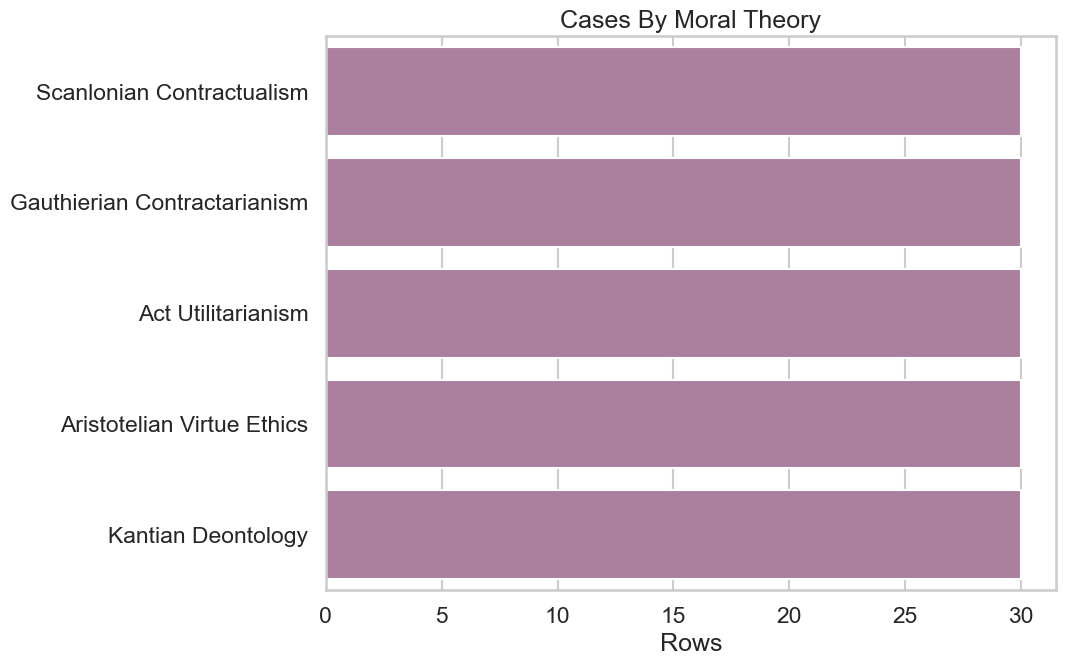

In [14]:
theory_counts = raw_df["THEORY"].fillna("unknown").value_counts().rename_axis("THEORY").reset_index(name="count")
plt.figure(figsize=(11, 7))
sns.barplot(data=theory_counts, x="count", y="THEORY", color="#B279A2")
plt.title("Cases By Moral Theory")
plt.xlabel("Rows")
plt.ylabel("")
plt.tight_layout()
plt.show()


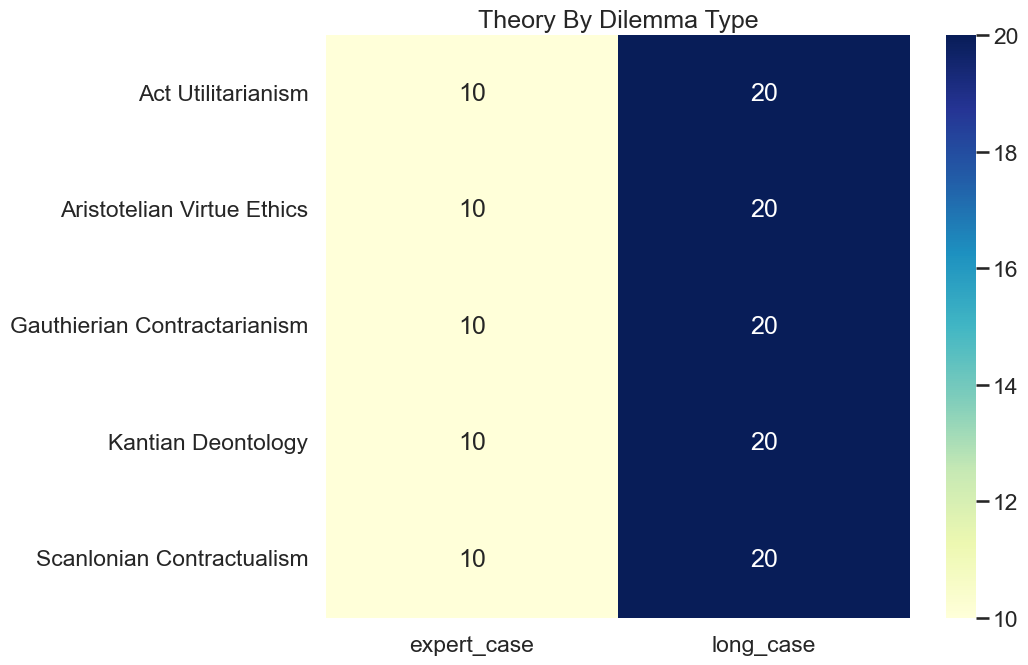

In [15]:
theory_type = pd.crosstab(raw_df["THEORY"], raw_df["DILEMMA_TYPE"])
plt.figure(figsize=(11, 7))
sns.heatmap(theory_type, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Theory By Dilemma Type")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()


In [16]:
comparison_df = pd.DataFrame([
    {"stage": "raw", "rows": len(raw_df), "evaluation_style": "rubric-based", "flat_training_label": "no"},
    {"stage": "processed", "rows": len(processed_df), "evaluation_style": "rubric-based", "flat_training_label": "no"},
])
markdown("### Raw vs Processed Comparison")
display(comparison_df)


### Raw vs Processed Comparison

,stage,rows,evaluation_style,flat_training_label
0,raw,150,rubric-based,no
1,processed,150,rubric-based,no


## Key Takeaways

- These rows are open-ended dilemmas, so example displays and rubric summaries are more informative than ordinary class-balance plots.
- The benchmark is evaluation-oriented rather than simple right/wrong classification.
- The processed version mostly standardizes the table structure for downstream use; it does not convert the benchmark into a flat supervised label dataset.
